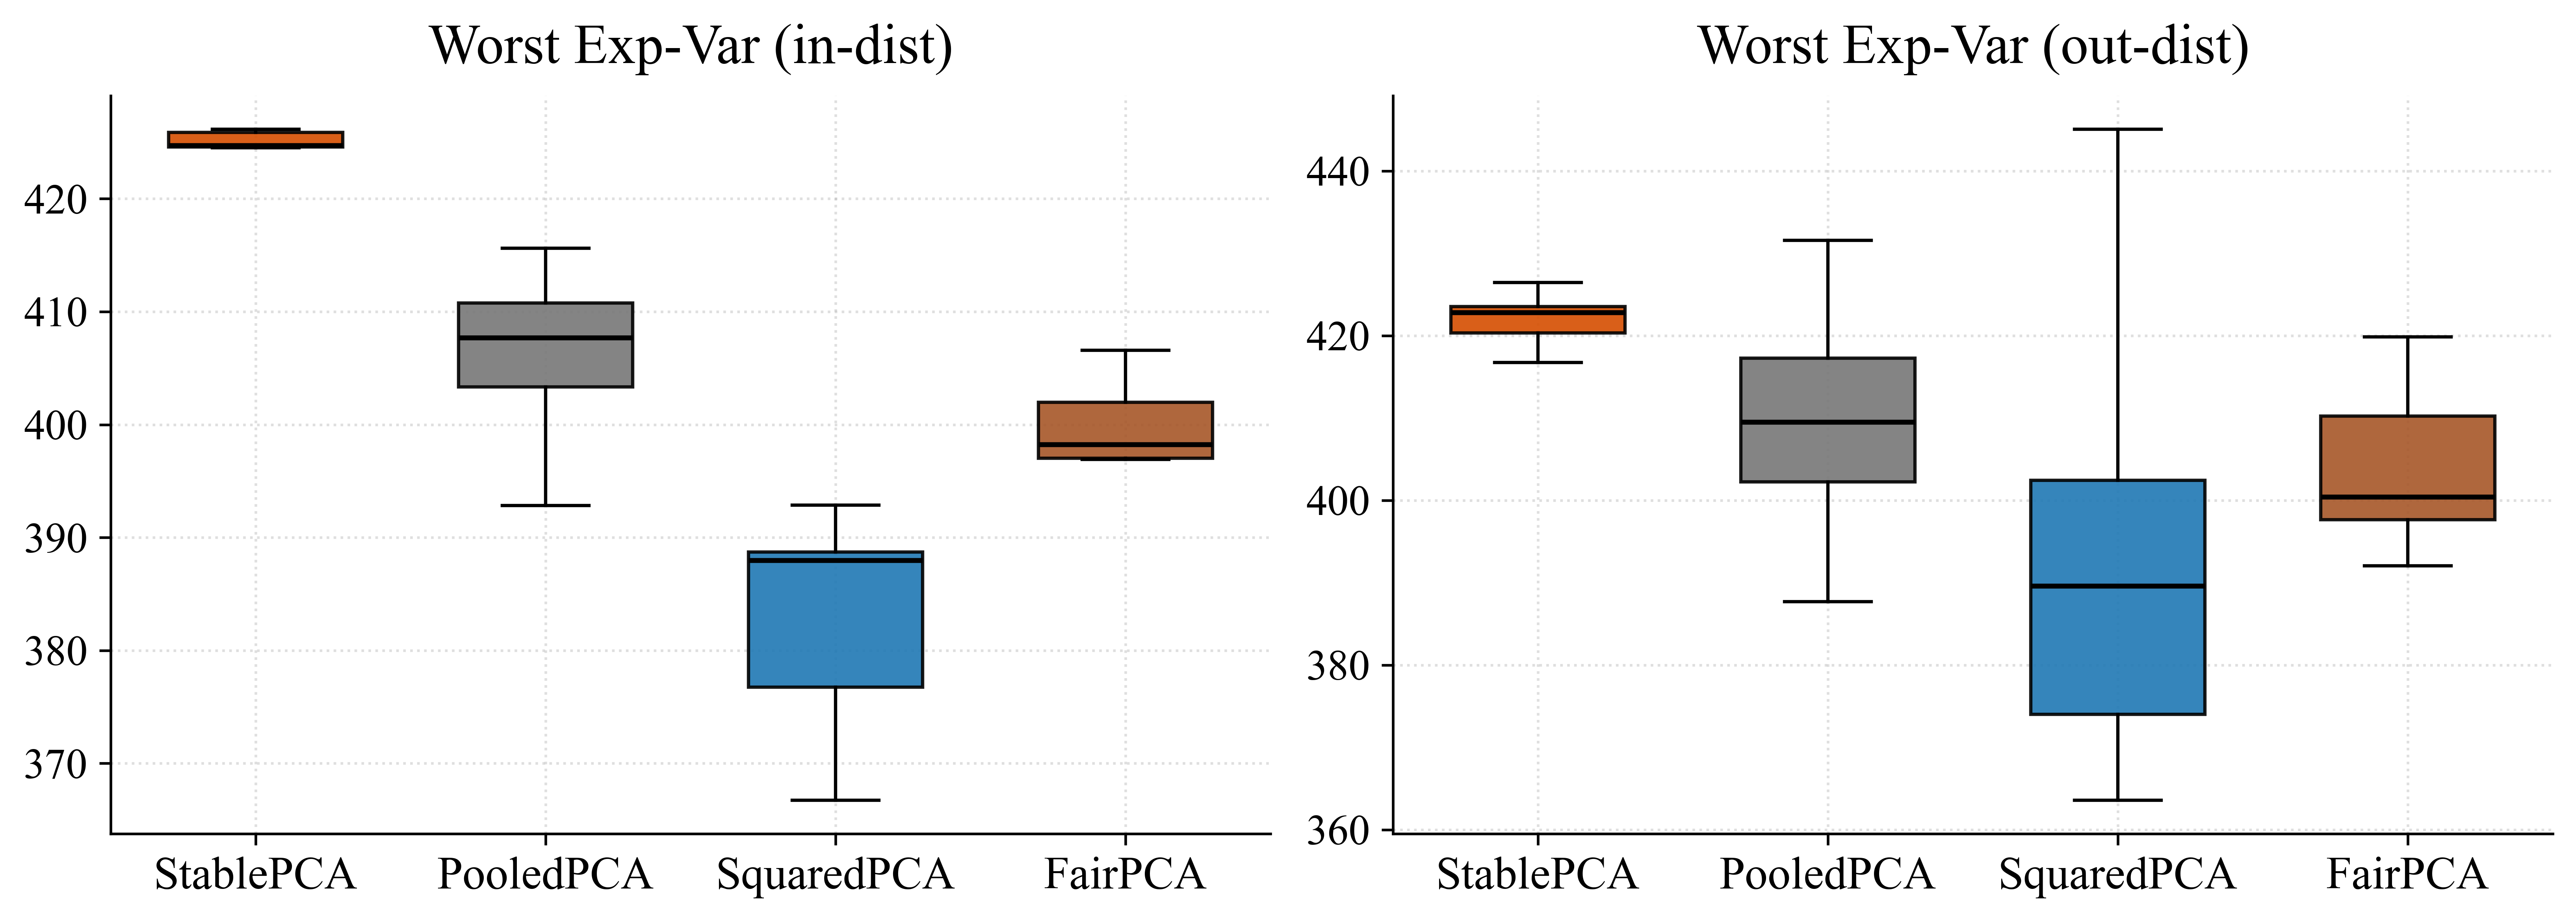

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# NeurIPS-ish global style (your previous setup)
# ------------------------------------------------------------
plt.rcParams.update({
    # --- NeurIPS-style, larger text for print ---
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "figure.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",

    # Scaled up for visibility in print
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 13,
    "legend.fontsize": 15,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

# ------------------------------------------------------------
# Method labels and colors (consistent with your scheme)
# ------------------------------------------------------------
methods = ["stable", "pooled", "squared", "fair"]
method_labels = {
    "stable":  "StablePCA",
    "pooled":  "PooledPCA",
    "squared": "SquaredPCA",
    "fair":    "FairPCA",
}
method_colors = {
    "pooled":  "#777777",  # charcoal
    "stable":  "#D54E00",  # orange
    "squared": "#1F78B4",  # blue
    "fair":    "#A65628",  # brownish
}

# ------------------------------------------------------------
# Aggregate results across jobs
# ------------------------------------------------------------
results_dir = "../saved_results/real_application"
num_jobs = 20

# one list per method
in_all = {m: [] for m in methods}
out_all = {m: [] for m in methods}

for job in range(num_jobs):
    fpath = os.path.join(results_dir, f"rotation_test_results_job{job}.pkl")
    if not fpath.exists():
        print(f"⚠️ Missing file: {fpath}")
        continue
    with open(fpath, "rb") as f:
        res = pickle.load(f)

    for m in methods:
        in_key = f"{m}_in"
        out_key = f"{m}_out"
        if in_key in res:
            in_all[m].extend(res[in_key])
        if out_key in res:
            out_all[m].extend(res[out_key])

# Convert to ordered lists for plotting
in_data = [np.array(in_all[m]) for m in methods]
out_data = [np.array(out_all[m]) for m in methods]
box_labels = [method_labels[m] for m in methods]
box_colors = [method_colors[m] for m in methods]

# ------------------------------------------------------------
# Plot: two subfigures, in-dist & out-dist
# ------------------------------------------------------------
fig, (ax_in, ax_out) = plt.subplots(1, 2, figsize=(11, 4))
plt.subplots_adjust(wspace=0.25, bottom=0.18)

# Helper to style a boxplot axis
def style_boxplot(ax, title, ylabel=None):
    ax.set_title(title, pad=10)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# --- Left: In-distribution worst-case explained variance ---
bp_in = ax_in.boxplot(
    in_data,
    tick_labels=box_labels,
    showfliers=False,        # remove outliers for better visualization
    patch_artist=True,
    widths=0.6,
)

for patch, c in zip(bp_in["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)
for median in bp_in["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# # Add mean markers (black diamonds)
# for i, data in enumerate(in_data, start=1):
#     mean_val = np.mean(data)
#     ax_in.scatter(i, mean_val, color="black", marker="D", s=28, zorder=3)

style_boxplot(
    ax_in,
    title=r"Worst Exp-Var (in-dist)",
    ylabel=None,
)

# --- Right: Out-of-distribution worst-case explained variance ---
bp_out = ax_out.boxplot(
    out_data,
    tick_labels=box_labels,
    showfliers=False,
    patch_artist=True,
    widths=0.6,
)

for patch, c in zip(bp_out["boxes"], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.9)
for median in bp_out["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)
    
# # Add mean markers (black diamonds)
# for i, data in enumerate(out_data, start=1):
#     mean_val = np.mean(data)
#     ax_out.scatter(i, mean_val, color="black", marker="D", s=28, zorder=3)

style_boxplot(
    ax_out,
    title=r"Worst Exp-Var (out-dist)",
    ylabel=None,
)

plt.tight_layout()
# Optional: save
# plt.savefig("Figures/single_cell.png", dpi=600, bbox_inches="tight")
plt.show()
